In [1]:
!pip install segmentation-models-pytorch torch torchmetrics albumentations

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 6.5 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=0e21c88281a61a36ceac39ed4d88fdaf1c2bec85d6515769c7e6df9c741ee080
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=a2f7c43093bd7dc6cf82db53518285e3f24347994ef60aa0a5e75b9f48b00b52
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-pytorch pretrainedmodels


In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchmetrics.classification import BinaryJaccardIndex, BinaryAccuracy
from torchmetrics import Dice
import torchvision.models as models
import torch.nn.functional as F
from torch.nn import init
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split

from albumentations.pytorch import ToTensorV2
import albumentations as A
import segmentation_models_pytorch as smp

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [3]:
BASE_DATA_DIR = "/kaggle/input/kvasir-segmentation/Kvasir-SEG"  # Change this to the folder containing "images" and "masks"
IMAGE_DIR = os.path.join(BASE_DATA_DIR, "images")
MASK_DIR  = os.path.join(BASE_DATA_DIR, "masks")

image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith('.jpg')])
mask_files  = sorted([f for f in os.listdir(MASK_DIR) if f.lower().endswith('.jpg')])

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

Number of images: 1000
Number of masks: 1000


Resolution statistics:
             Width       Height
count  1000.000000  1000.000000
mean    625.292000   545.228000
std     129.621142    90.690798
min     332.000000   352.000000
25%     591.750000   529.000000
50%     621.000000   530.000000
75%     622.000000   531.000000
max    1920.000000  1072.000000


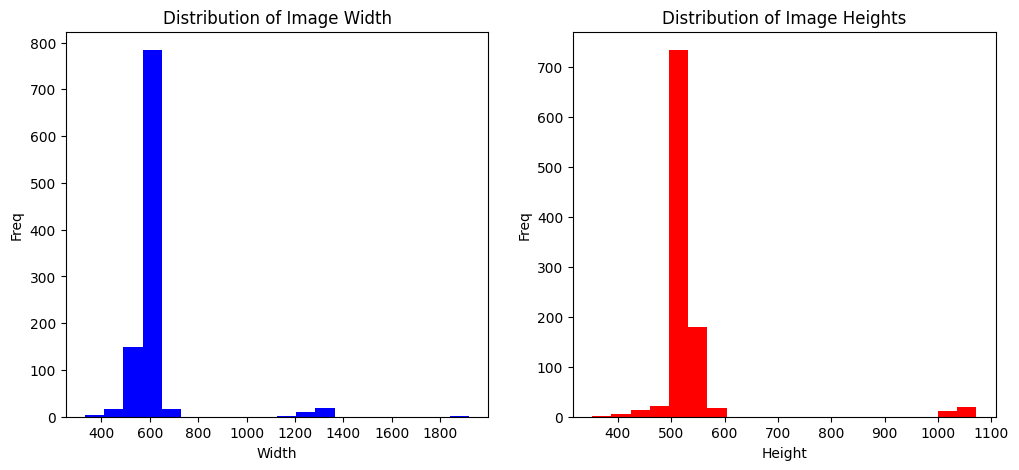

In [4]:
# %% [code]
resolutions = []
for f in image_files:
    img_path = os.path.join(IMAGE_DIR, f)
    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]
    resolutions.append((w, h))

res_df = pd.DataFrame(resolutions, columns=['Width', 'Height'])
print("Resolution statistics:")
print(res_df.describe())

# Plot histogram of widths and heights.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(res_df['Width'], bins=20, color='b')
plt.title('Distribution of Image Width')
plt.xlabel('Width')
plt.ylabel('Freq')

plt.subplot(1, 2, 2)
plt.hist(res_df['Height'], bins=20, color='r')
plt.title('Distribution of Image Heights')
plt.xlabel('Height')
plt.ylabel('Freq')

plt.show()

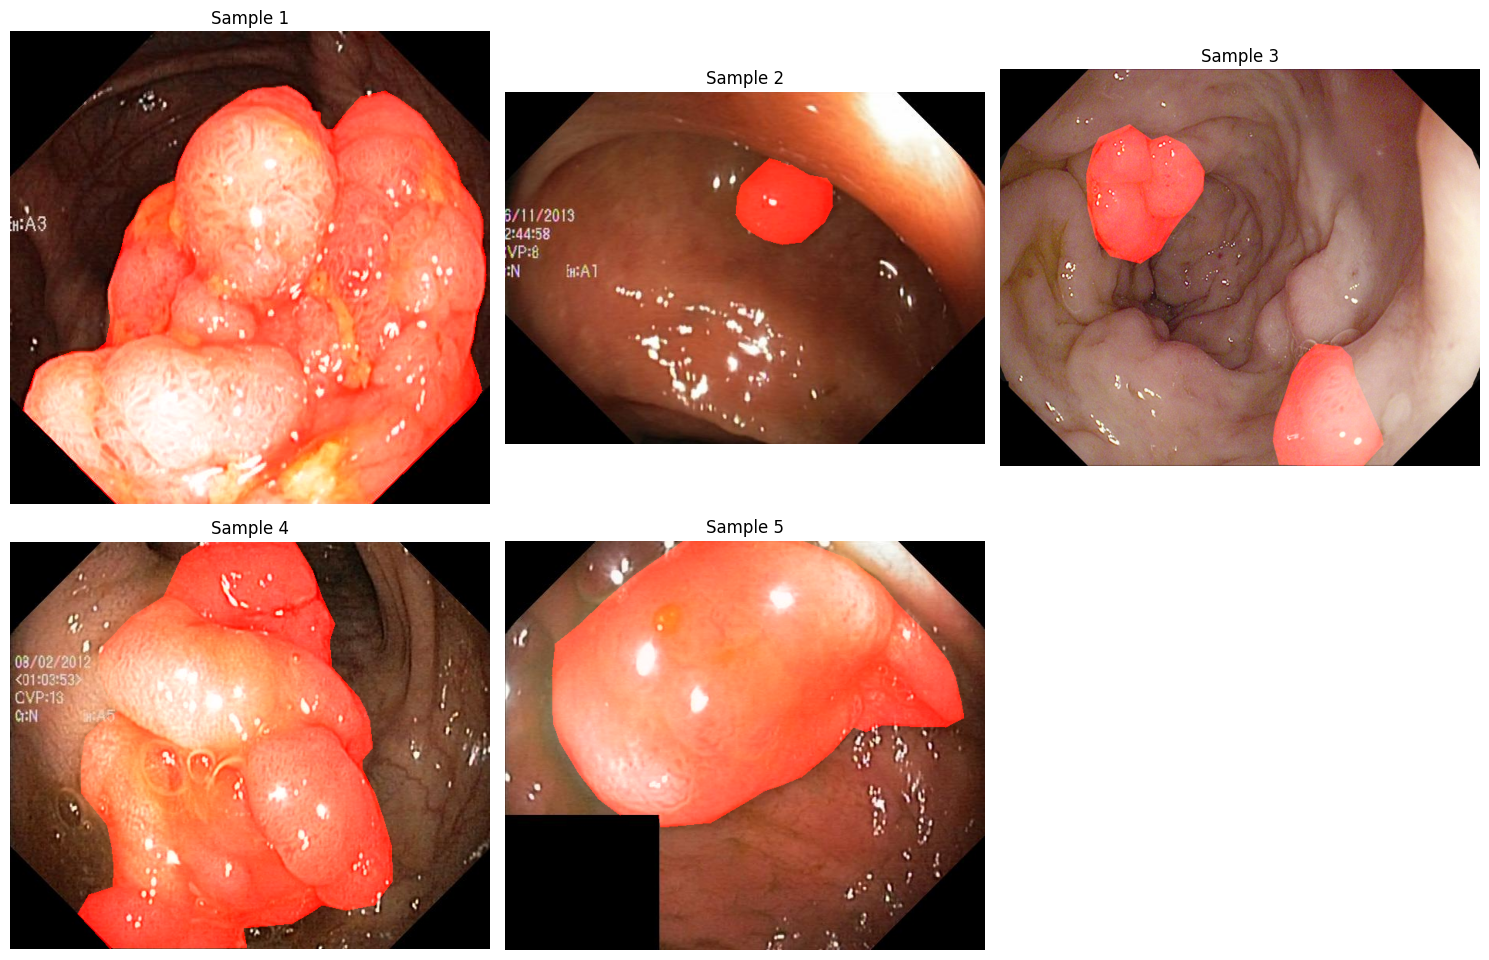

In [5]:
def overlay_mask(image, mask, mask_color=(255, 0, 0), alpha=0.8):
    """
    Overlays the binary mask on the image.
    :param image: PIL Image.
    :param mask: PIL Image (grayscale) or array of mask.
    :param mask_color: Color for the mask overlay.
    :param alpha: Transparency for overlay.
    :return: Combined image as a numpy array.
    """
    image = np.array(image).astype(np.uint8)
    if isinstance(mask, Image.Image):
        mask = np.array(mask)
    # Ensure mask is binary:
    mask = (mask > 127).astype(np.uint8)
    color_mask = np.zeros_like(image)
    color_mask[mask == 1] = mask_color
    overlayed = cv2.addWeighted(image, 1.0, color_mask, alpha, 0)
    return overlayed

# %% [code]
# Show 5 random samples:
sample_indices = random.sample(range(len(image_files)), 5)
plt.figure(figsize=(15, 10))
for i, idx in enumerate(sample_indices):
    img_path = os.path.join(IMAGE_DIR, image_files[idx])
    mask_path = os.path.join(MASK_DIR, image_files[idx])  # Assuming identical filename.
    
    image = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")
    
    overlayed = overlay_mask(image, mask)
    
    plt.subplot(2, 3, i+1)
    plt.imshow(overlayed)
    plt.title(f"Sample {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Average foreground percentage: 15.39%


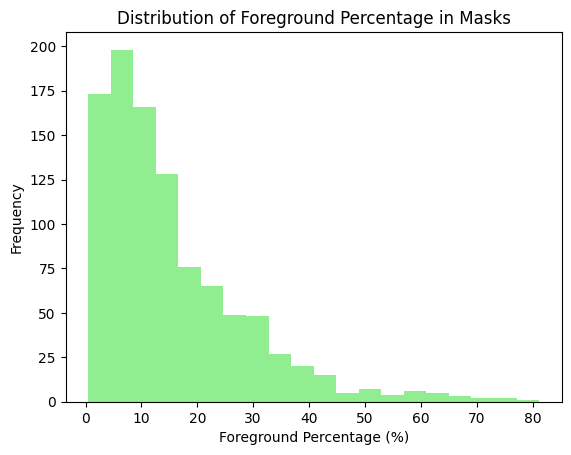

In [6]:
foreground_percentages = []
for f in image_files:
    mask_path = os.path.join(MASK_DIR, f)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        continue
    # Binarize the mask.
    _, mask_bin = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)
    # Calculate percentage of white (foreground).
    percentage = np.sum(mask_bin == 255) / mask_bin.size * 100
    foreground_percentages.append(percentage)
    
print("Average foreground percentage: {:.2f}%".format(np.mean(foreground_percentages)))
plt.hist(foreground_percentages, bins=20, color='lightgreen')
plt.title("Distribution of Foreground Percentage in Masks")
plt.xlabel("Foreground Percentage (%)")
plt.ylabel("Frequency")
plt.show()

In [7]:
# Define transforms (example using albumentations)
train_transforms = A.Compose([
    A.Resize(512, 512), 
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # Optionally add color jitter, small elastic transforms, etc.
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# A custom dataset that applies these transforms.
class KvasirSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, file_list=None, transform=None):
        """
        Args:
            image_dir (str): Directory containing the images.
            mask_dir (str): Directory containing the masks.
            file_list (list, optional): List of filenames to use. If None, the 
                dataset scans the entire folder.
            transform (albumentations.Compose, optional): Transformation pipeline.
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        if file_list is None:
            self.image_files = sorted([f for f in os.listdir(image_dir)
                                        if f.lower().endswith('.jpg')])
        else:
            self.image_files = sorted(file_list)
        self.transform = transform
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        f = self.image_files[idx]
        image_path = os.path.join(self.image_dir, f)
        mask_path  = os.path.join(self.mask_dir, f)  # Assumes masks share the same filenames.
        
        image = np.array(Image.open(image_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"), dtype=np.uint8)
        # Binarize the mask: pixels greater than 127 become 1, else 0.
        mask = np.where(mask > 127, 1, 0).astype(np.uint8)
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask  = augmented['mask']
        
        return image, mask

# ---------------------------------------------------------------------
# 4. Get All Filenames and Split into Training and Validation Sets
# ---------------------------------------------------------------------
all_files = sorted([f for f in os.listdir(IMAGE_DIR) 
                    if f.lower().endswith('.jpg')])
print("Total samples:", len(all_files))

train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

# ---------------------------------------------------------------------
# 5. Create Dataset Instances Using the Split File Lists
# ---------------------------------------------------------------------
train_dataset = KvasirSegDataset(IMAGE_DIR, MASK_DIR, file_list=train_files, transform=train_transforms)
val_dataset   = KvasirSegDataset(IMAGE_DIR, MASK_DIR, file_list=val_files, transform=val_transforms)

print("Total training samples:", len(train_dataset))
print("Total validation samples:", len(val_dataset))

Total samples: 1000
Total training samples: 800
Total validation samples: 200


In [8]:
# -------------------------------------------------------
# 5. Create DataLoader Objects
# -------------------------------------------------------
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# -------------------------------------------------------
# 6. Define the U-Net Model (ResNet34 Encoder)
# -------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="resnet34",        # Using ResNet34 as encoder
    encoder_weights="imagenet",       # Using ImageNet pretrained weights
    in_channels=3,
    classes=1,                        # Binary segmentation
)
model = model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 422MB/s]


In [9]:
# 7. Define Loss Function, Optimizer, and Metrics
# Loss function
loss_fn = smp.losses.DiceLoss(mode='binary')

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Metrics
iou_metric = BinaryJaccardIndex(threshold=0.5).to(device)
accuracy_metric = BinaryAccuracy(threshold=0.5).to(device)
dice_metric = Dice(threshold=0.5).to(device)

In [10]:
# -------------------------------------------------------
# 8. Training Loop
# -------------------------------------------------------
num_epochs = 25
patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0

score_history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_accuracy': [],
    'val_dice': []
}


for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device).float().unsqueeze(1)  # Ensure shape [B, 1, H, W]
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
    
    avg_train_loss = train_loss / len(train_loader.dataset)
    
    model.eval()
    val_loss = 0.0
    iou_metric.reset()
    accuracy_metric.reset()
    dice_metric.reset()
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device).float().unsqueeze(1)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            val_loss += loss.item() * images.size(0)
            
            outputs = torch.sigmoid(outputs)
            preds = (outputs > 0.5).float()
            preds_int = preds.long()
            masks_int = masks.long()
            
            # Update metrics:
            iou_metric.update(preds_int, masks_int)
            accuracy_metric.update(preds_int, masks_int)
            dice_metric.update(preds_int, masks_int)
    
    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_iou = iou_metric.compute().item()
    avg_acc = accuracy_metric.compute().item()
    avg_dice = dice_metric.compute().item()
    
    # Early stopping check.
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        # Optionally, save the best model:
        torch.save(model.state_dict(), "/kaggle/working/KvasirUnet_34_best.pth")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break
    
    score_history['epoch'].append(epoch + 1)
    score_history['train_loss'].append(avg_train_loss)
    score_history['val_loss'].append(avg_val_loss)
    score_history['val_iou'].append(avg_iou)
    score_history['val_accuracy'].append(avg_acc)
    score_history['val_dice'].append(avg_dice)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val IoU: {avg_iou:.4f}, Val Accuracy: {avg_acc:.4f}, Val Dice: {avg_dice:.4f}")

Epoch [1/25]
Train Loss: 0.5376
Val Loss: 0.4191, Val IoU: 0.6326, Val Accuracy: 0.9163, Val Dice: 0.9163
Epoch [2/25]
Train Loss: 0.3895
Val Loss: 0.3156, Val IoU: 0.7042, Val Accuracy: 0.9418, Val Dice: 0.9418
Epoch [3/25]
Train Loss: 0.2952
Val Loss: 0.2553, Val IoU: 0.7180, Val Accuracy: 0.9451, Val Dice: 0.9451
Epoch [4/25]
Train Loss: 0.2283
Val Loss: 0.1976, Val IoU: 0.7563, Val Accuracy: 0.9542, Val Dice: 0.9542
Epoch [5/25]
Train Loss: 0.2012
Val Loss: 0.1816, Val IoU: 0.7573, Val Accuracy: 0.9533, Val Dice: 0.9533
Epoch [6/25]
Train Loss: 0.1810
Val Loss: 0.1971, Val IoU: 0.7192, Val Accuracy: 0.9481, Val Dice: 0.9481
Epoch [7/25]
Train Loss: 0.1723
Val Loss: 0.1815, Val IoU: 0.7239, Val Accuracy: 0.9483, Val Dice: 0.9483
Epoch [8/25]
Train Loss: 0.1510
Val Loss: 0.1383, Val IoU: 0.7852, Val Accuracy: 0.9605, Val Dice: 0.9605
Epoch [9/25]
Train Loss: 0.1352
Val Loss: 0.1642, Val IoU: 0.7361, Val Accuracy: 0.9509, Val Dice: 0.9509
Epoch [10/25]
Train Loss: 0.1352
Val Loss: 0.1

In [11]:
torch.save(model.state_dict(), "/kaggle/working/KvasirUnet_34_final.pth")

In [12]:
df_scores = pd.DataFrame(score_history)
df_scores.to_csv("/kaggle/working/KvasirUnet_34_scores.csv", index=False)
print("Training scores saved.")

Training scores saved.
